In [69]:
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Statistics

from scipy import stats

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_palette("Set2")

In [70]:
df = pd.read_csv("Finance.csv")

df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


# Model Comparison (R² Score Bar Chart)

In [71]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [72]:
# Step 2: Define Features and Target
# Target Variable
y = df["Disposable_Income"]

# Feature Variables
X = df.drop("Disposable_Income", axis=1)

In [73]:
# Step 3: Encode Categorical Columns
categorical_cols = ['Occupation', 'City_Tier']
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [74]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [75]:
# Step 5: Train All Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

r2_scores = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    prediction = pipeline.predict(X_test)

    r2 = r2_score(y_test, prediction)

    r2_scores[name] = r2

In [76]:
# Step 6: Display R² Scores
results = pd.DataFrame({
    "Model": list(r2_scores.keys()),
    "R² Score": list(r2_scores.values())
})

results = results.sort_values(
    by="R² Score",
    ascending=False
)

print(results)

               Model  R² Score
0  Linear Regression  1.000000
2      Random Forest  0.906692
1      Decision Tree  0.838568


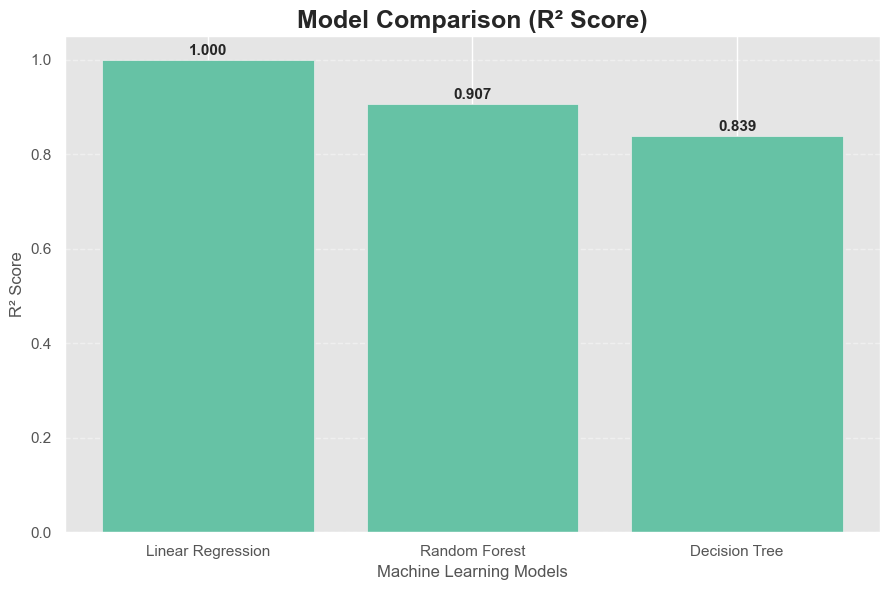

In [77]:
# Step 7: Plot Model Comparison Bar Chart
plt.figure(figsize=(9,6))

bars = plt.bar(
    results["Model"],
    results["R² Score"]
)

plt.title(
    "Model Comparison (R² Score)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Models", fontsize=12)

plt.ylabel("R² Score", fontsize=12)

plt.ylim(0, 1.05)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Model_Comparison_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance (Random Forest)

In [78]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [79]:
# Step 2: Define Features & Target
# Target Variable
y = df["Disposable_Income"]

# Features
X = df.drop("Disposable_Income", axis=1)

In [80]:
# Step 3: Separate Categorical & Numerical Columns
categorical_cols = ['Occupation', 'City_Tier']

numeric_cols = X.select_dtypes(include=['int64','float64']).columns

In [81]:
# Step 4: Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [82]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [83]:
# Step 6: Build Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Occupation', 'City_Tier']),
                                                 ('num', 'passthrough',
                                                  Index(['Income', 'Age', 'Dependents', 'Rent', 'Loan_Repayment', 'Insurance',
       'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
       'Healthcare', 'Education', 'Miscellaneous',
       'Desired_Savin...ed_Savings',
       'Potential_Savings_Groceries', 'Potential_Savings_Transport',
       'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment',
       'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
       'Potential_Savings_Education', 'Potential_Savings_Miscellaneous'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [84]:
# Step 7: Extract Feature Names
# Encoded categorical feature names
encoded_cat = rf_pipeline.named_steps['preprocessor'] \
                         .named_transformers_['cat'] \
                         .get_feature_names_out(categorical_cols)

# Final feature names
feature_names = list(encoded_cat) + list(numeric_cols)

In [85]:
# Step 8: Get Feature Importance
importance = rf_pipeline.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [86]:
# Step 9: Display Top Features
print(feature_importance.head(15))

                         Feature  Importance
22               Desired_Savings    0.817448
11                Loan_Repayment    0.045605
7                         Income    0.037213
4               City_Tier_Tier_1    0.029755
10                          Rent    0.007812
28  Potential_Savings_Healthcare    0.006662
29   Potential_Savings_Education    0.006201
19                     Education    0.006141
21    Desired_Savings_Percentage    0.005940
14                     Transport    0.004001
18                    Healthcare    0.003255
15                    Eating_Out    0.003040
9                     Dependents    0.002822
13                     Groceries    0.002752
17                     Utilities    0.002654


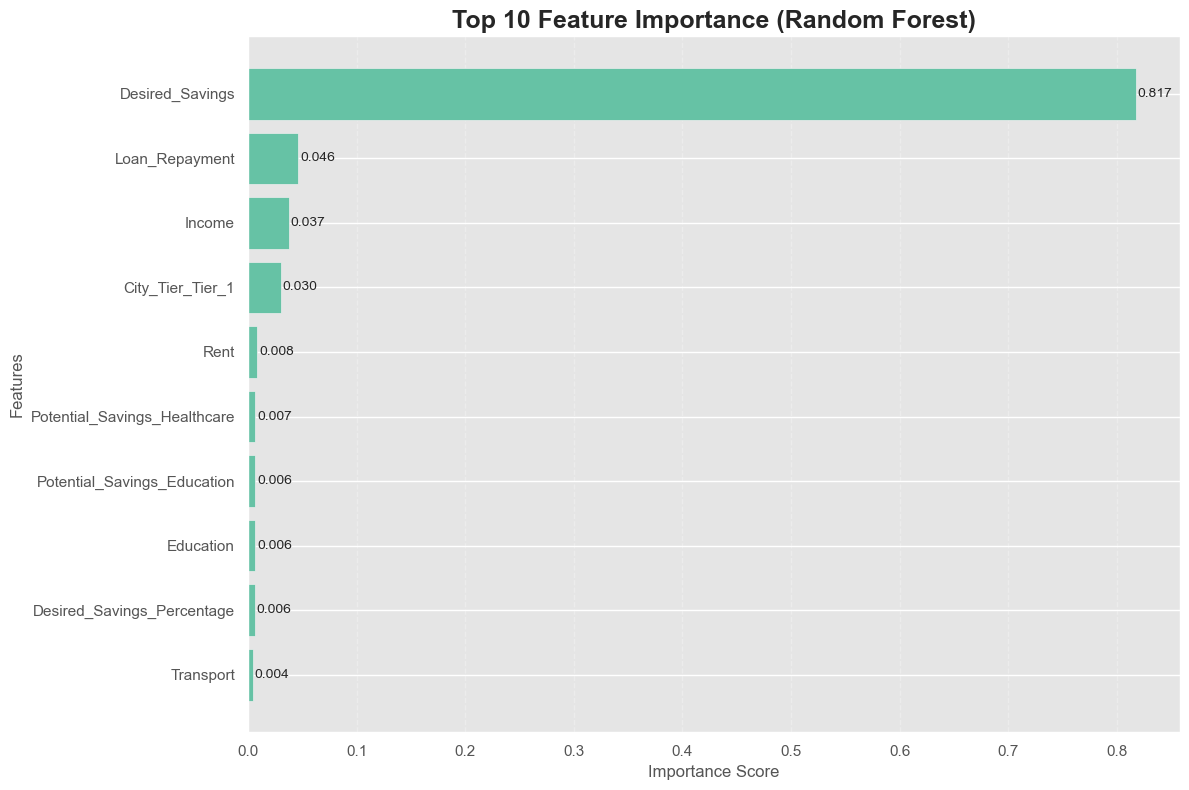

In [88]:
# Step 10: Plot Feature Importance
plt.figure(figsize=(12,8))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Feature Importance (Random Forest)",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Importance Score", fontsize=12)

plt.ylabel("Features", fontsize=12)

plt.gca().invert_yaxis()

# Add labels
for index, value in enumerate(top_features["Importance"]):
    plt.text(
        value + 0.002,
        index,
        f"{value:.3f}",
        va='center',
        fontsize=10
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "RandomForest_Feature_Importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()